# 🏥 Disease Prediction from Medical Data
**CodeAlpha ML Internship — Task 4**

Predicts diseases using structured medical datasets:
- ❤️ Heart Disease (Cleveland UCI)
- 🩸 Diabetes (Pima Indians)
- 🔬 Breast Cancer (Wisconsin)

Algorithms: Logistic Regression, Random Forest, XGBoost, SVM

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from sklearn.pipeline import Pipeline
import joblib

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed. Run: pip install xgboost')

DATA_DIR   = './data'
MODELS_DIR = './models'
os.makedirs(MODELS_DIR, exist_ok=True)

print('Libraries loaded successfully!')
print(f'Data dir: {os.path.abspath(DATA_DIR)}')

Libraries loaded successfully!
Data dir: d:\CodeAlpha Internship\Disease Prediction from Medical Data\data


## 1. Load & Explore Datasets

In [2]:
# ── Heart Disease ──────────────────────────────────────────────────────────
heart = pd.read_csv(os.path.join(DATA_DIR, 'heart.csv'))
# Rename target if needed
if 'target' not in heart.columns and 'condition' in heart.columns:
    heart.rename(columns={'condition': 'target'}, inplace=True)
heart['target'] = (heart['target'] > 0).astype(int)  # binary: 0=no disease, 1=disease
print('❤️  Heart Disease:', heart.shape)
print(heart['target'].value_counts().to_dict(), '\n')

# ── Diabetes ───────────────────────────────────────────────────────────────
diabetes = pd.read_csv(os.path.join(DATA_DIR, 'diabetes.csv'))
print('🩸 Diabetes:', diabetes.shape)
print(diabetes['Outcome'].value_counts().to_dict(), '\n')

# ── Breast Cancer ──────────────────────────────────────────────────────────
bc = pd.read_csv(os.path.join(DATA_DIR, 'breast_cancer.csv'))
# Drop id and unnamed columns
bc.drop(columns=[c for c in bc.columns if 'id' in c.lower() or 'unnamed' in c.lower()],
        errors='ignore', inplace=True)
# Encode diagnosis: M=1 (malignant), B=0 (benign)
if 'diagnosis' in bc.columns:
    bc['diagnosis'] = LabelEncoder().fit_transform(bc['diagnosis'])
print('🔬 Breast Cancer:', bc.shape)
print(bc['diagnosis'].value_counts().to_dict())

❤️  Heart Disease: (1025, 14)
{1: 526, 0: 499} 

🩸 Diabetes: (768, 9)
{0: 500, 1: 268} 

🔬 Breast Cancer: (569, 31)
{0: 357, 1: 212}


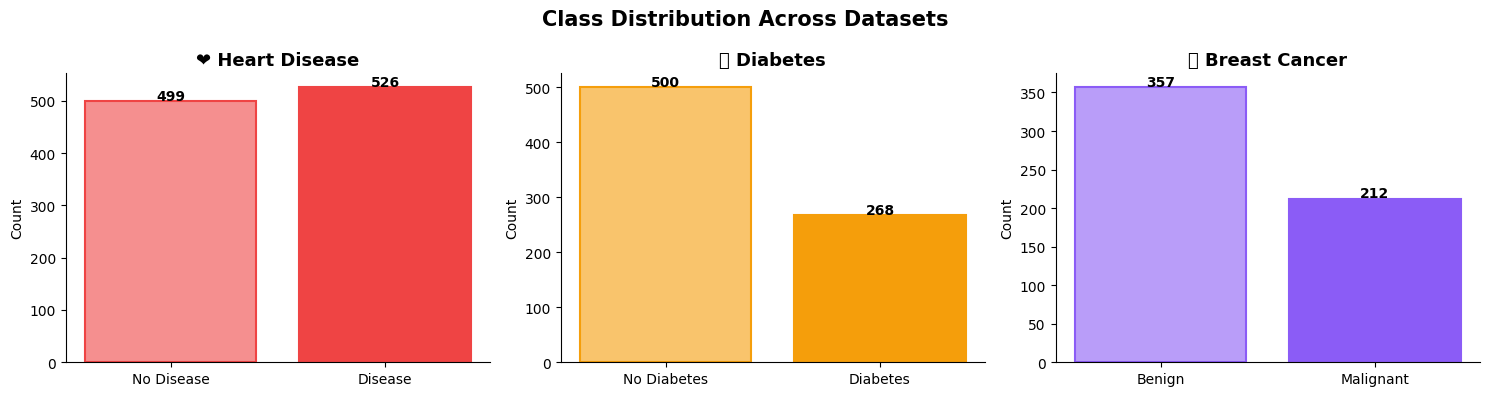

In [3]:
# ── Overview of all datasets ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

datasets = [
    (heart,    'target',    ['No Disease', 'Disease'],   '❤️ Heart Disease',   '#ef4444'),
    (diabetes, 'Outcome',   ['No Diabetes','Diabetes'],  '🩸 Diabetes',         '#f59e0b'),
    (bc,       'diagnosis', ['Benign',     'Malignant'], '🔬 Breast Cancer',    '#8b5cf6'),
]

for ax, (df, col, lbls, title, color) in zip(axes, datasets):
    counts = df[col].value_counts().sort_index()
    bars   = ax.bar(lbls, counts.values, color=[color+'99', color], edgecolor=color, linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(v),
                ha='center', fontweight='bold')
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Class Distribution Across Datasets', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. EDA & Correlation Analysis

Missing Values:
  Heart: 0 missing values
  Diabetes: 0 missing values
  Breast Cancer: 0 missing values


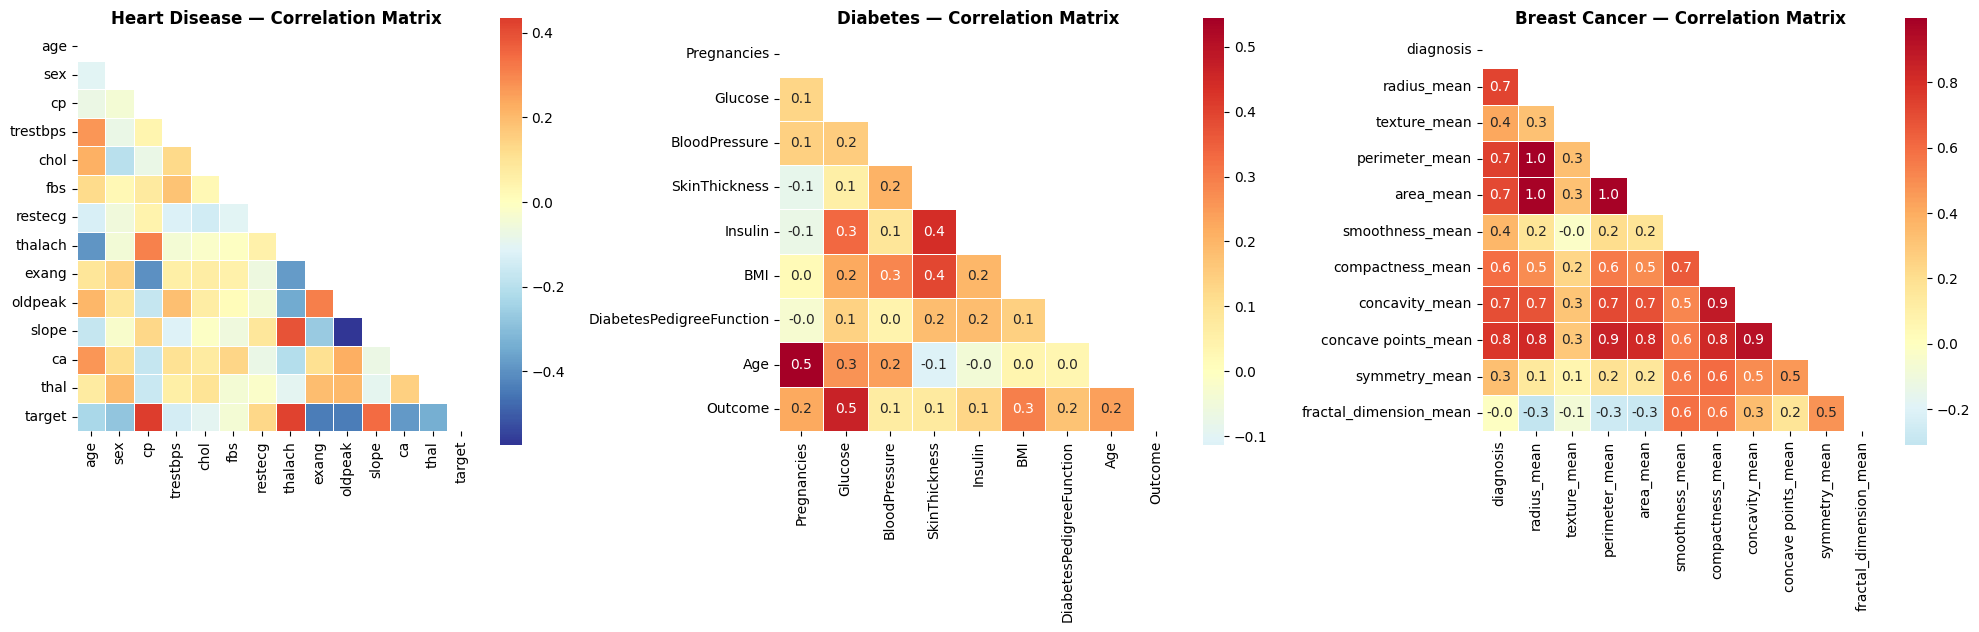

In [4]:
# ── Missing values check ───────────────────────────────────────────────────
print('Missing Values:')
for name, df in [('Heart', heart), ('Diabetes', diabetes), ('Breast Cancer', bc)]:
    mv = df.isnull().sum().sum()
    print(f'  {name}: {mv} missing values')

# ── Correlation heatmaps ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
configs = [
    (heart,           'Heart Disease',  '#ef4444'),
    (diabetes,        'Diabetes',       '#f59e0b'),
    (bc.iloc[:, :11], 'Breast Cancer',  '#8b5cf6'),
]
for ax, (df, title, color) in zip(axes, configs):
    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, ax=ax, mask=mask, cmap='RdYlBu_r',
                center=0, annot=len(df.columns)<=12,
                fmt='.1f', linewidths=0.5, square=True)
    ax.set_title(f'{title} — Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Preprocessing

In [5]:
def prepare_data(df, target_col, test_size=0.2, random_state=42):
    """Split features/target and create train/test sets."""
    df = df.dropna()
    X  = df.drop(columns=[target_col])
    y  = df[target_col]
    # Keep only numeric columns
    X  = X.select_dtypes(include=[np.number])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    print(f'Train: {X_train.shape} | Test: {X_test.shape} | Features: {list(X.columns)}')
    return X_train, X_test, y_train, y_test, list(X.columns)

print('❤️  Heart Disease:')
H_Xtr, H_Xte, H_ytr, H_yte, H_feats = prepare_data(heart,    'target')
print('\n🩸 Diabetes:')
D_Xtr, D_Xte, D_ytr, D_yte, D_feats = prepare_data(diabetes, 'Outcome')
print('\n🔬 Breast Cancer:')
B_Xtr, B_Xte, B_ytr, B_yte, B_feats = prepare_data(bc,       'diagnosis')

❤️  Heart Disease:
Train: (820, 13) | Test: (205, 13) | Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

🩸 Diabetes:
Train: (614, 8) | Test: (154, 8) | Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

🔬 Breast Cancer:
Train: (455, 30) | Test: (114, 30) | Features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


## 4. Train & Compare Models

In [6]:
def get_models():
    models = {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(max_iter=1000, random_state=42))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    RandomForestClassifier(n_estimators=200, random_state=42))
        ]),
        'SVM': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    SVC(probability=True, random_state=42))
        ]),
        'Gradient Boosting': Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    GradientBoostingClassifier(n_estimators=200, random_state=42))
        ]),
    }
    if HAS_XGB:
        models['XGBoost'] = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    XGBClassifier(n_estimators=200, random_state=42,
                                     eval_metric='logloss', verbosity=0))
        ])
    return models


def train_and_evaluate(X_train, X_test, y_train, y_test, dataset_name, color):
    """Train all models, return results dict + best model."""
    models  = get_models()
    results = {}
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    print(f'\n{dataset_name}')
    print('─' * 65)
    print(f'{"Model":<22} {"CV Acc":>8} {"Test Acc":>9} {"F1":>8} {"ROC-AUC":>9}')
    print('─' * 65)

    best_auc, best_name, best_model = 0, '', None

    for name, pipe in models.items():
        cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
        pipe.fit(X_train, y_train)
        y_pred      = pipe.predict(X_test)
        y_pred_prob = pipe.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred, average='weighted')
        auc = roc_auc_score(y_test, y_pred_prob)

        results[name] = {
            'cv_acc': cv_scores.mean(), 'test_acc': acc,
            'f1': f1, 'auc': auc,
            'y_pred': y_pred, 'y_pred_prob': y_pred_prob, 'model': pipe
        }
        print(f'{name:<22} {cv_scores.mean():>8.4f} {acc:>9.4f} {f1:>8.4f} {auc:>9.4f}')

        if auc > best_auc:
            best_auc, best_name, best_model = auc, name, pipe

    print('─' * 65)
    print(f'Best model: {best_name} (ROC-AUC: {best_auc:.4f})')
    return results, best_name, best_model


H_results, H_best_name, H_best = train_and_evaluate(H_Xtr, H_Xte, H_ytr, H_yte, '❤️  Heart Disease',  '#ef4444')
D_results, D_best_name, D_best = train_and_evaluate(D_Xtr, D_Xte, D_ytr, D_yte, '🩸 Diabetes',         '#f59e0b')
B_results, B_best_name, B_best = train_and_evaluate(B_Xtr, B_Xte, B_ytr, B_yte, '🔬 Breast Cancer',    '#8b5cf6')


❤️  Heart Disease
─────────────────────────────────────────────────────────────────
Model                    CV Acc  Test Acc       F1   ROC-AUC
─────────────────────────────────────────────────────────────────
Logistic Regression      0.8427    0.8098   0.8072    0.9298
Random Forest            0.9805    1.0000   1.0000    1.0000
SVM                      0.8951    0.9268   0.9268    0.9771
Gradient Boosting        0.9780    0.9805   0.9805    0.9996
XGBoost                  0.9866    1.0000   1.0000    1.0000
─────────────────────────────────────────────────────────────────
Best model: Random Forest (ROC-AUC: 1.0000)

🩸 Diabetes
─────────────────────────────────────────────────────────────────
Model                    CV Acc  Test Acc       F1   ROC-AUC
─────────────────────────────────────────────────────────────────
Logistic Regression      0.7882    0.7143   0.7084    0.8230
Random Forest            0.7687    0.7468   0.7437    0.8146
SVM                      0.7785    0.7532   0.

## 5. Visualise Results

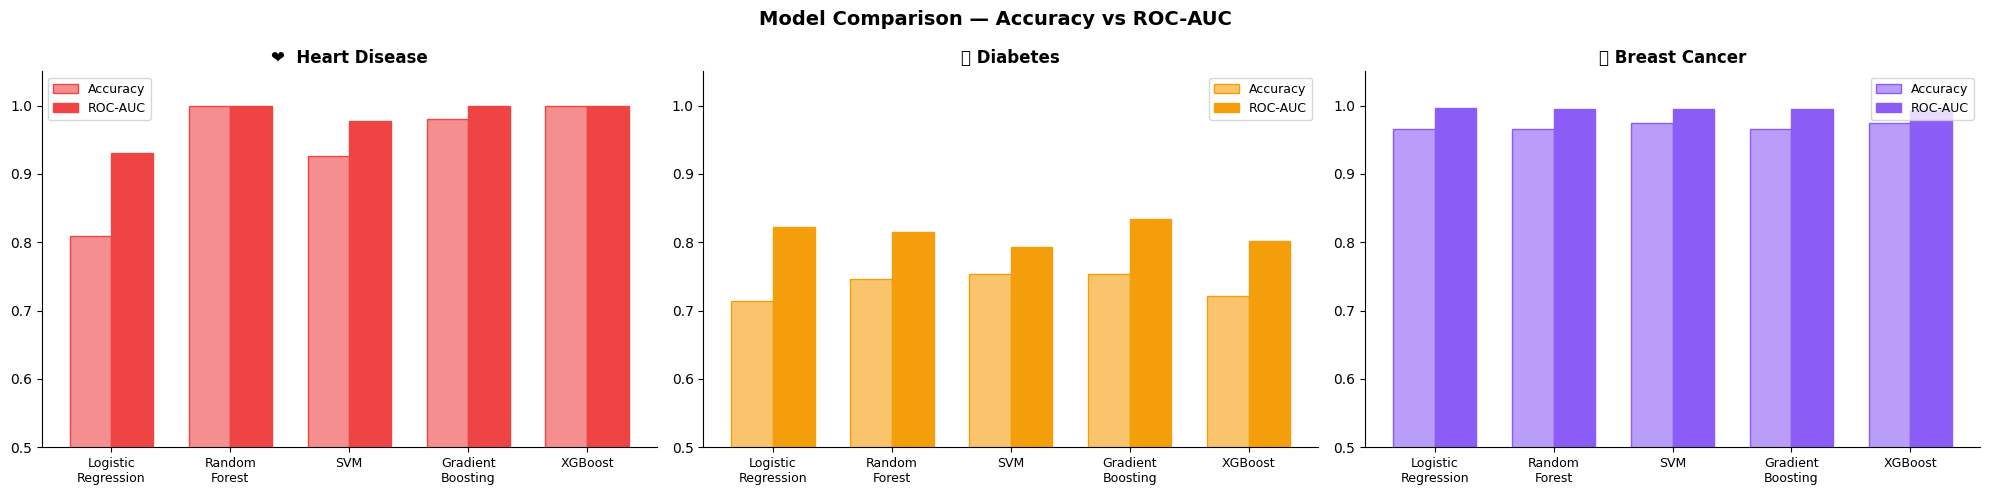

In [7]:
# ── Model comparison bar charts ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
configs = [
    (H_results, '❤️  Heart Disease',  '#ef4444'),
    (D_results, '🩸 Diabetes',         '#f59e0b'),
    (B_results, '🔬 Breast Cancer',    '#8b5cf6'),
]
for ax, (results, title, color) in zip(axes, configs):
    names = list(results.keys())
    accs  = [results[n]['test_acc'] for n in names]
    aucs  = [results[n]['auc']      for n in names]
    x     = np.arange(len(names))
    w     = 0.35
    ax.bar(x - w/2, accs, w, label='Accuracy', color=color+'99', edgecolor=color)
    ax.bar(x + w/2, aucs, w, label='ROC-AUC',  color=color,      edgecolor=color)
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
    ax.set_ylim(0.5, 1.05)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Model Comparison — Accuracy vs ROC-AUC', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

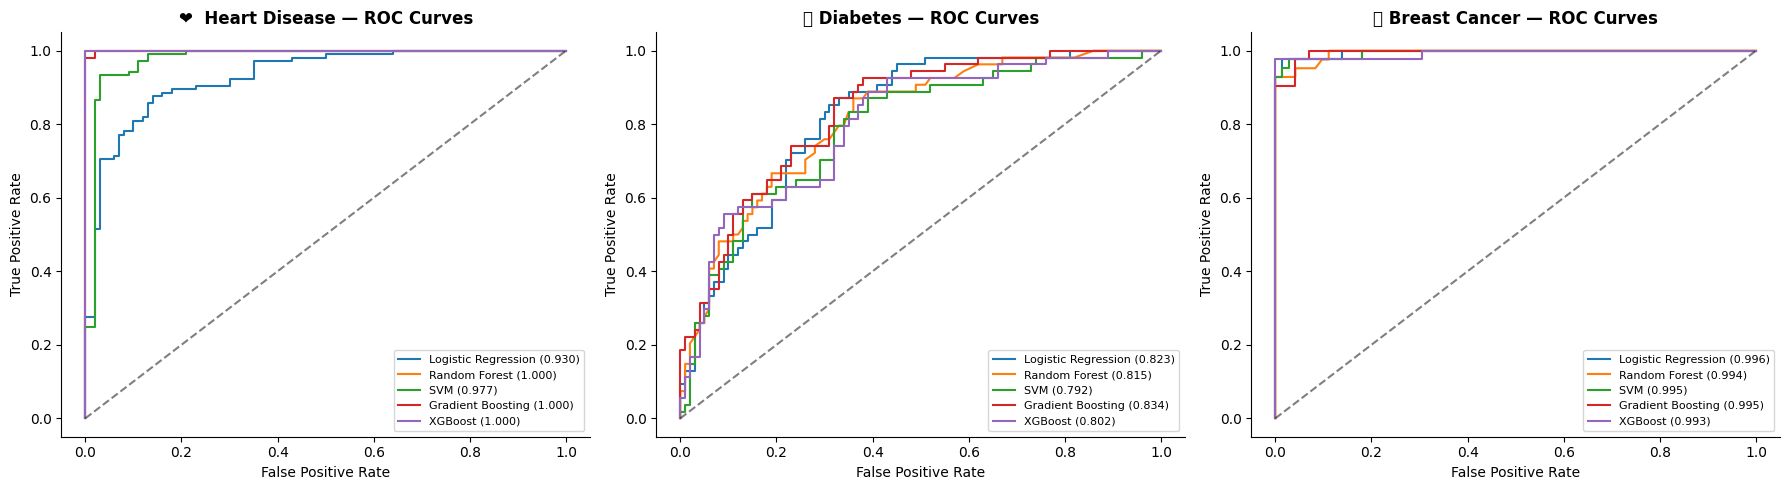

In [8]:
# ── ROC Curves ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
roc_configs = [
    (H_results, H_yte, '❤️  Heart Disease',  '#ef4444'),
    (D_results, D_yte, '🩸 Diabetes',         '#f59e0b'),
    (B_results, B_yte, '🔬 Breast Cancer',    '#8b5cf6'),
]
for ax, (results, y_test, title, color) in zip(axes, roc_configs):
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(y_test, res['y_pred_prob'])
        ax.plot(fpr, tpr, label=f"{name} ({res['auc']:.3f})")
    ax.plot([0,1],[0,1],'k--', alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{title} — ROC Curves', fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

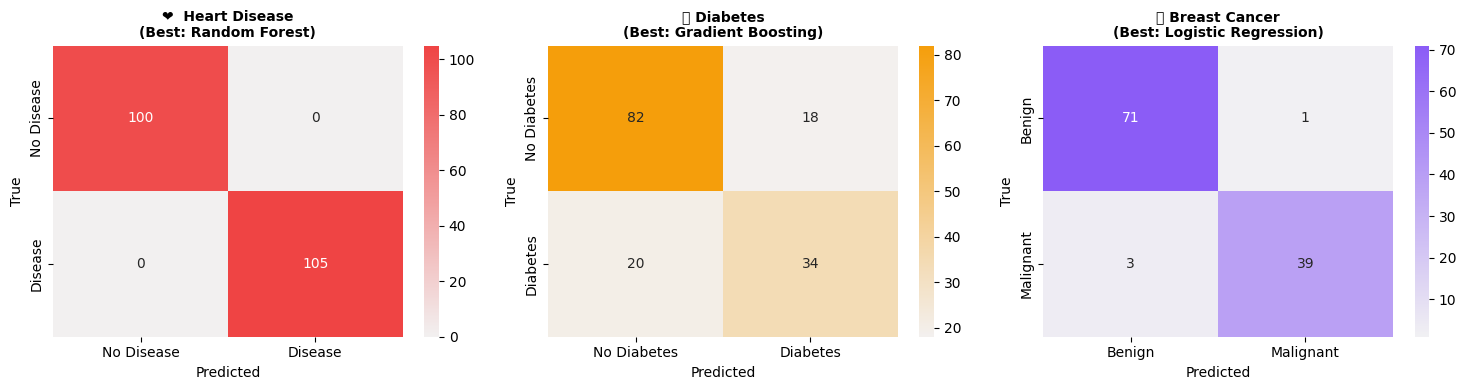

In [9]:
# ── Confusion Matrices (best models) ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cm_configs = [
    (H_results[H_best_name], H_yte, ['No Disease','Disease'],   '❤️  Heart Disease',  '#ef4444'),
    (D_results[D_best_name], D_yte, ['No Diabetes','Diabetes'], '🩸 Diabetes',         '#f59e0b'),
    (B_results[B_best_name], B_yte, ['Benign','Malignant'],     '🔬 Breast Cancer',    '#8b5cf6'),
]
for ax, (res, y_test, lbls, title, color) in zip(axes, cm_configs):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=lbls, yticklabels=lbls,
                cmap=sns.light_palette(color, as_cmap=True))
    ax.set_title(f'{title}\n(Best: {H_best_name if "Heart" in title else D_best_name if "Diab" in title else B_best_name})',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

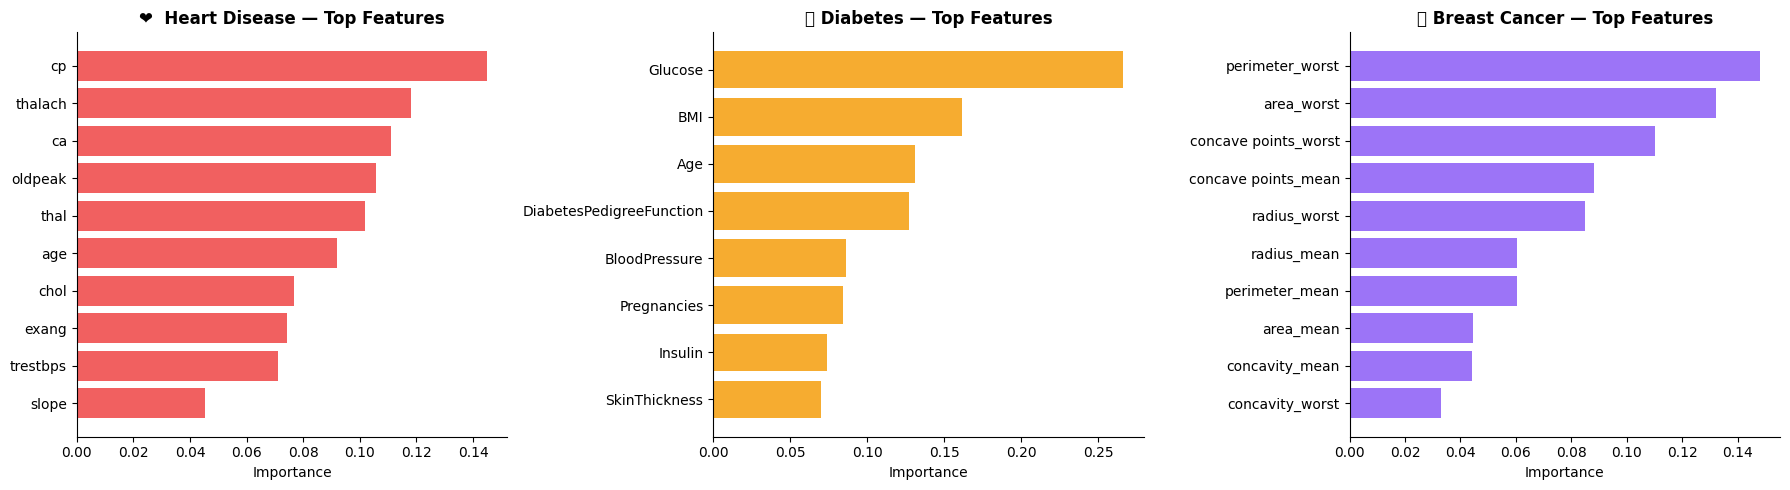

In [10]:
# ── Feature Importance (Random Forest) ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fi_configs = [
    (H_results, H_feats, '❤️  Heart Disease',  '#ef4444'),
    (D_results, D_feats, '🩸 Diabetes',         '#f59e0b'),
    (B_results, B_feats, '🔬 Breast Cancer',    '#8b5cf6'),
]
for ax, (results, feats, title, color) in zip(axes, fi_configs):
    rf_pipe = results['Random Forest']['model']
    imp     = rf_pipe.named_steps['clf'].feature_importances_
    indices = np.argsort(imp)[::-1][:10]
    ax.barh([feats[i] for i in indices[::-1]], imp[indices[::-1]],
            color=color, alpha=0.85)
    ax.set_title(f'{title} — Top Features', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Save Best Models

In [11]:
# Save best model for each disease
joblib.dump(H_best, os.path.join(MODELS_DIR, 'heart_model.pkl'))
joblib.dump(D_best, os.path.join(MODELS_DIR, 'diabetes_model.pkl'))
joblib.dump(B_best, os.path.join(MODELS_DIR, 'breast_cancer_model.pkl'))

# Save feature names
import json
feature_info = {
    'heart':        H_feats,
    'diabetes':     D_feats,
    'breast_cancer': B_feats
}
with open(os.path.join(MODELS_DIR, 'feature_info.json'), 'w') as f:
    json.dump(feature_info, f)

print('=' * 50)
print('  Models saved to ./models/')
print(f'  ❤️  Heart    — Best: {H_best_name} | AUC: {H_results[H_best_name]["auc"]:.4f}')
print(f'  🩸 Diabetes  — Best: {D_best_name} | AUC: {D_results[D_best_name]["auc"]:.4f}')
print(f'  🔬 Breast Ca — Best: {B_best_name} | AUC: {B_results[B_best_name]["auc"]:.4f}')
print('  Run: streamlit run app.py')
print('=' * 50)

  Models saved to ./models/
  ❤️  Heart    — Best: Random Forest | AUC: 1.0000
  🩸 Diabetes  — Best: Gradient Boosting | AUC: 0.8335
  🔬 Breast Ca — Best: Logistic Regression | AUC: 0.9960
  Run: streamlit run app.py
